# 75 — Persistent tracker MATLAB/Python comparison

This notebook repeats the previous comparison with the same `UltraTimTrack_test.mp4`, ROI JSON, MATLAB result, seed settings, aponeurosis gates, and normal/adaptive Kalman settings. The only algorithmic differences are the new persistent KLT tracker state and affine-aware two-state Kalman prediction.

The primary parity target is the normal fixed-R branch, because it corresponds most closely to the saved MATLAB run.

In [1]:
from __future__ import annotations

import json
import os
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
VIDEO = ROOT / 'data' / 'raw' / 'UltraTimTrack_test.mp4'
ROI_PATH = ROOT / 'data' / 'rois' / 'UltraTimTrack_test_rois.json'
MATLAB_RESULT = ROOT / 'data' / 'matlab' / 'slow_low_01_DOWN_tracked_Q=001.mat'
RUN_ROOT = ROOT / 'results' / 'notebook75_persistent_tracker_matlab_python' / 'python_updated_exact_same_inputs'
RUN_DIR = RUN_ROOT / VIDEO.stem
UPDATED_NPZ = RUN_DIR / f'{VIDEO.stem}_strict_results.npz'
OUT = ROOT / 'results' / 'notebook75_persistent_tracker_matlab_python'
UTT_EXPORT = next((path for path in [
    ROOT / 'data' / 'matlab' / 'UTT_numeric_export.mat',
    Path('/Users/grosbedou/Documents/GitHub/UltraTimTrack/UTT_numeric_export.mat'),
] if path.exists()), None)

for required in [VIDEO, ROI_PATH, MATLAB_RESULT]:
    assert required.exists(), required

print('Video:', VIDEO)
print('ROI:', ROI_PATH, json.loads(ROI_PATH.read_text()))
print('MATLAB result:', MATLAB_RESULT)
print('Updated Python result:', UPDATED_NPZ)

Video: /Users/grosbedou/PycharmProjects/NDORMS/data/raw/UltraTimTrack_test.mp4
ROI: /Users/grosbedou/PycharmProjects/NDORMS/data/rois/UltraTimTrack_test_rois.json {'superficial': [20, 18, 685, 54], 'deep': [16, 302, 689, 76], 'fascicle': [23, 78, 679, 218]}
MATLAB result: /Users/grosbedou/PycharmProjects/NDORMS/data/matlab/slow_low_01_DOWN_tracked_Q=001.mat
Updated Python result: /Users/grosbedou/PycharmProjects/NDORMS/results/notebook75_persistent_tracker_matlab_python/python_updated_exact_same_inputs/UltraTimTrack_test/UltraTimTrack_test_strict_results.npz


## Exact same-input rerun

Set `FORCE_RERUN = True` to repeat the full 2,667-frame pipeline. With a current result present, this cell remains fast and uses the saved updated run.

In [2]:
FORCE_RERUN = False

runner_command = [
    sys.executable,
    str(ROOT / 'scripts' / 'run_ultratimtrack_adaptive_confidence.py'),
    str(VIDEO),
    '--roi-path', str(ROI_PATH),
    '--utt-export', str(UTT_EXPORT),
    '--results-dir', str(RUN_ROOT),
    '--seed-frames', '11',
    '--apo-maxangle', '10',
    '--candidate-persistence',
    '--apo-gating',
    '--kalman-mode', 'adaptive-anisotropic',
    '--compare-to-fixed-kalman',
    '--save-confidence-plots',
    '--no-annotated-video',
    '--save-overlays', '2',
    '--no-time-series-plot',
    '--progress-every', '100',
]

if FORCE_RERUN or not UPDATED_NPZ.exists():
    if UTT_EXPORT is None:
        raise FileNotFoundError('UTT_numeric_export.mat is required for a fresh rerun.')
    env = dict(os.environ)
    env.setdefault('MPLCONFIGDIR', '/private/tmp/matplotlib')
    subprocess.run(runner_command, cwd=ROOT, env=env, check=True)
else:
    print('Using completed updated run:', UPDATED_NPZ)

Using completed updated run: /Users/grosbedou/PycharmProjects/NDORMS/results/notebook75_persistent_tracker_matlab_python/python_updated_exact_same_inputs/UltraTimTrack_test/UltraTimTrack_test_strict_results.npz


## Final outputs and saved tracker/Kalman states

In [3]:
compare_command = [
    sys.executable,
    str(ROOT / 'scripts' / 'compare_updated_matlab_python.py'),
]
subprocess.run(compare_command, cwd=ROOT, check=True)

agreement = pd.read_csv(OUT / 'agreement_metrics.csv')
improvement = pd.read_csv(OUT / 'before_after_improvement.csv')
state_metrics = pd.read_csv(OUT / 'tracker_kalman_state_metrics.csv')
tracker_summary = json.loads((OUT / 'tracker_state_summary.json').read_text())

The updated fixed-R Python run is closer to MATLAB on both primary outputs.
  method variable unit  before_bias  after_bias  before_mae  after_mae  mae_change_after_minus_before  before_rmse  after_rmse  rmse_change_after_minus_before  rmse_percent_change  before_lins_ccc  after_lins_ccc  ccc_change_after_minus_before
  normal    FL_mm   mm    -1.774770   -1.793345    2.112008   1.912003                      -0.200005     2.549416    1.995396                       -0.554020           -21.731248         0.963823        0.978159                       0.014335
  normal  ANG_deg  deg     1.006280    1.034021    1.138250   1.073847                      -0.064403     1.393651    1.166109                       -0.227541           -16.327006         0.958649        0.971152                       0.012503
  normal  PEN_deg  deg     0.938173    0.965914    1.091325   1.008360                      -0.082965     1.330771    1.094590                       -0.236180           -17.747619         0.95

In [4]:
display(Markdown('### Fixed-R before/after'))
display(improvement[improvement['method'] == 'normal'].reset_index(drop=True))
display(Markdown('### All final-output agreement metrics'))
display(agreement)

### Fixed-R before/after

,method,variable,unit,before_bias,after_bias,before_mae,after_mae,mae_change_after_minus_before,before_rmse,after_rmse,rmse_change_after_minus_before,rmse_percent_change,before_lins_ccc,after_lins_ccc,ccc_change_after_minus_before
0,normal,FL_mm,mm,-1.774770,-1.793345,2.112008,1.912003,-0.200005,2.549416,1.995396,-0.554020,-21.731248,0.963823,0.978159,0.014335
1,normal,ANG_deg,deg,1.006280,1.034021,1.138250,1.073847,-0.064403,1.393651,1.166109,-0.227541,-16.327006,0.958649,0.971152,0.012503
2,normal,PEN_deg,deg,0.938173,0.965914,1.091325,1.008360,-0.082965,1.330771,1.094590,-0.236180,-17.747619,0.957215,0.971118,0.013904


### All final-output agreement metrics

,run,method,variable,unit,python_offset,n,bias,mae,rmse,max_abs,pearson_r,lins_ccc
0,previous,normal,FL_mm,mm,1,2666,-1.774770,2.112008,2.549416,5.827917,0.981023,0.963823
1,previous,normal,ANG_deg,deg,1,2666,1.006280,1.138250,1.393651,4.276031,0.983148,0.958649
2,previous,normal,PEN_deg,deg,1,2666,0.938173,1.091325,1.330771,4.057621,0.980979,0.957215
3,previous,adaptive,FL_mm,mm,1,2666,-1.873780,2.135859,2.593571,6.037671,0.981713,0.962472
4,previous,adaptive,ANG_deg,deg,1,2666,1.055675,1.153223,1.406780,4.251895,0.984328,0.957851
5,previous,adaptive,PEN_deg,deg,1,2666,0.987568,1.096225,1.342695,4.033485,0.982257,0.956409
6,updated,normal,FL_mm,mm,1,2666,-1.793345,1.912003,1.995396,3.276762,0.995823,0.978159
7,updated,normal,ANG_deg,deg,1,2666,1.034021,1.073847,1.166109,2.241169,0.997300,0.971152
8,updated,normal,PEN_deg,deg,1,2666,0.965914,1.008360,1.094590,2.158315,0.996547,0.971118
9,updated,adaptive,FL_mm,mm,1,2666,-1.884983,1.997589,2.080296,3.347573,0.995773,0.976304


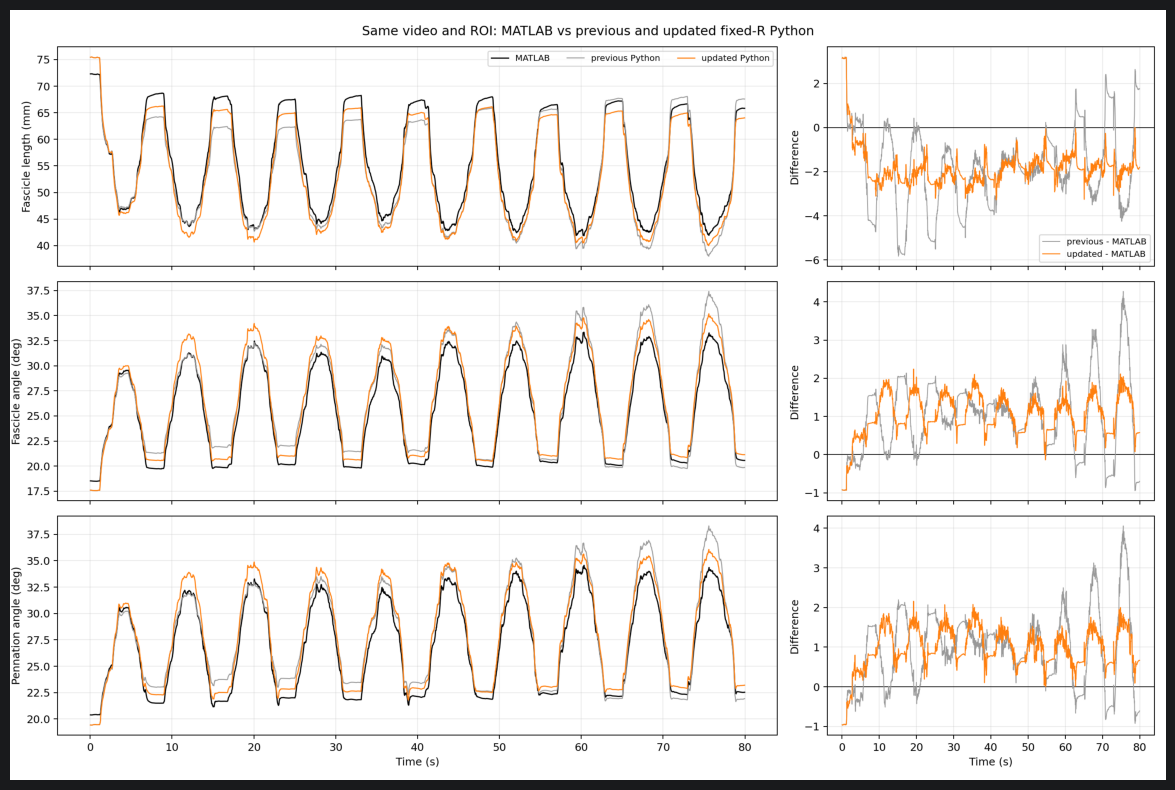

In [5]:
image = plt.imread(OUT / 'matlab_python_before_after.png')
plt.figure(figsize=(16, 10))
plt.imshow(image)
plt.axis('off')
plt.show()

## Internal-state parity

The table and plot below compare MATLAB's saved raw fascicle, forward `X_plus`, and reconstructed final state with the corresponding updated Python arrays.

,n_python_frames,n_matlab_rows,python_offset,matched_rows,affine_success_fraction,tracker_redetection_count_including_initialization,mean_tracker_found_fraction,median_tracker_point_count,median_affine_inlier_count,fixed_prediction_affine_fraction
0,2667,2666,1,2666,0.999625,0,0.999969,285.0,285.0,0.999625


,comparison,unit,n,bias,mae,rmse,max_abs,pearson_r,lins_ccc
0,raw_klt_x_superficial,px,2666,15.968458,15.968458,16.103270,21.808939,0.985873,0.537370
1,raw_klt_y_superficial,px,2666,2.191044,2.191362,2.603738,5.729787,0.880177,0.628876
2,raw_klt_x_deep,px,2666,-9.484930,9.553325,10.315669,25.700191,0.999324,0.995547
3,raw_klt_y_deep,px,2666,-3.863349,3.863566,4.454967,9.250337,0.893833,0.658838
4,raw_klt_angle,deg,2666,-1.488761,1.488761,1.597109,3.513462,0.997881,0.942375
5,raw_klt_segment_length,px,2666,20.386411,20.386970,21.146501,38.867867,0.998853,0.981313
6,forward_state_x,px,2666,18.676630,18.676630,18.750015,24.709144,0.983029,0.273330
7,forward_state_alpha,deg,2666,1.006874,1.082945,1.217969,2.661906,0.994435,0.968931
8,smoothed_state_x,px,2666,18.477752,18.477752,18.522364,23.105582,0.987037,0.247190
9,smoothed_state_alpha,deg,2666,1.034021,1.073847,1.166109,2.241169,0.997300,0.971152


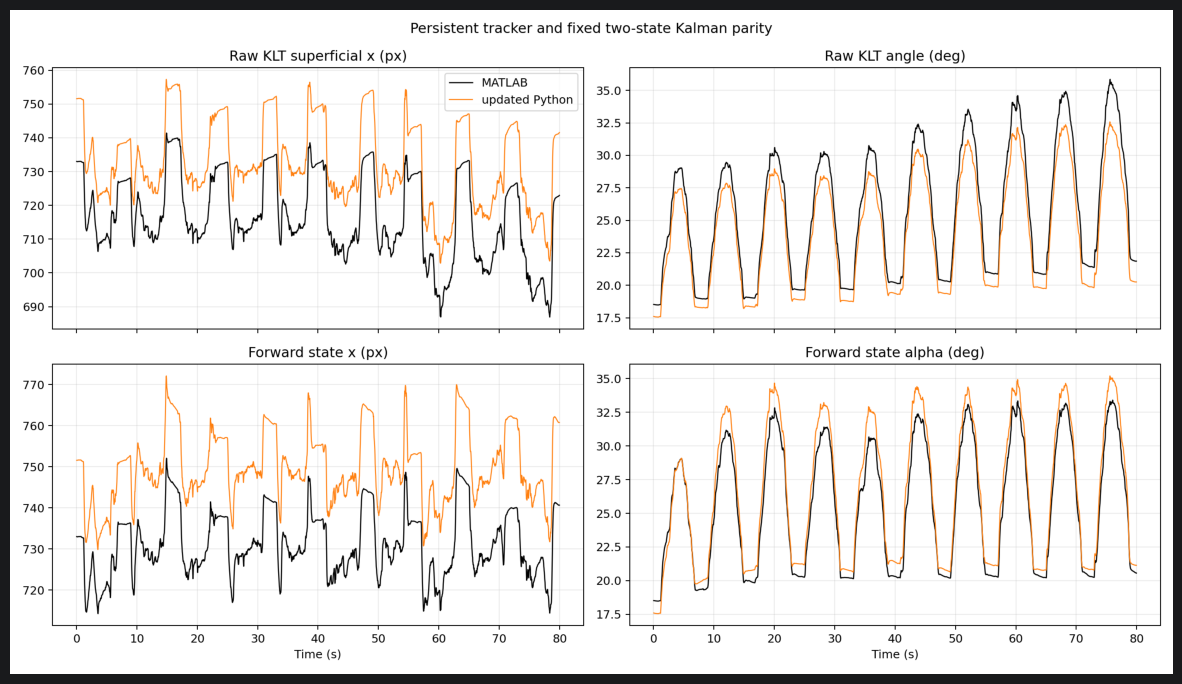

In [6]:
display(pd.DataFrame([tracker_summary]))
display(state_metrics)

image = plt.imread(OUT / 'tracker_kalman_state_comparison.png')
plt.figure(figsize=(15, 9))
plt.imshow(image)
plt.axis('off')
plt.show()

In [ ]:
display(Markdown((OUT / 'notebook75_summary.md').read_text()))